# Lake Breeze Detection and Instrument Steering over Chicago



This notebook walks through a complete AIDAS workflow:

1. **Preprocessing** — convert raw NEXRAD radar scans into model-ready images
2. **Inference** — run the lake breeze detection model to produce a binary mask
3. **Visualization** — overlay the mask on a radar reflectivity map
4. **Instrument steering** — compute the optimal azimuth for a ground instrument to scan the lake breeze front
5. **Occurrence analysis** — aggregate masks over time to map where the lake breeze appears most frequently

As a case study we examine the *pneumonia front* — a strong lake breeze intrusion — observed over the Chicago metro area on **April 24, 2025**.


## 1. Setup

Import the AIDAS library along with supporting packages for numerical computation, plotting, and map projections.


In [7]:
import aidas
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


## 2. Preprocessing Radar Data

AIDAS converts raw NEXRAD radar reflectivity fields into ImageNet-compatible images that can be fed directly to the detection model.

Two functions handle preprocessing:

| Function | Use case |
|---|---|
| `aidas.io.preprocess_radar_image` | Single scan — accepts a NEXRAD site ID + UTC time, or a Py-ART radar object |
| `aidas.io.preprocess_radar_image_batch` | Multiple scans — accepts a glob pattern; processes files in parallel via Dask by default (`parallel=True`) |

The cell below loads a batch of archived KLOT scans. Replace the glob pattern with the path to your own data.


In [ ]:
rad_scan1 = aidas.io.preprocess_radar_image_batch('/Users/rjackson/klot_batch_test/*_*V06', parallel=True)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather ra

For a single scan, pass the 4-letter NEXRAD site identifier and an ISO 8601 UTC timestamp. AIDAS fetches the nearest available volume from the NOAA archive and returns a `RadarImage` object. The `.pyart_object` attribute gives direct access to the underlying Py-ART radar object if you need lower-level data.


In [8]:
rad_scan = aidas.io.preprocess_radar_image('KLOT', '2025-04-24T19:42:38')
rad_scan.pyart_object.time

{'units': 'seconds since 2025-04-24T19:42:38Z',
 'standard_name': 'time',
 'long_name': 'time_in_seconds_since_volume_start',
 'calendar': 'gregorian',
 'comment': 'Coordinate variable for time. Time at the center of each ray, in fractional seconds since the global variable time_coverage_start',
 'data': array([  0.521,   0.626,   0.729, ..., 405.282, 405.338, 405.394],
       shape=(6480,))}

## 3. Running the Lake Breeze Detection Model


Pass the preprocessed `RadarImage` to `aidas.model.infer_lake_breeze`. The result is stored in the `.lakebreeze_mask` attribute as a binary NumPy array (1 = lake breeze detected, 0 = clear).

Two model variants are available via the `model_name` argument:

- `'lakebreeze_best_model_fcn_resnet50'` — the default production model
- `'lakebreeze_model_fcn_resnet50_no_augmentation'` — trained without data augmentation; can be useful for sensitivity comparisons

For batch inference over multiple time steps, use `aidas.model.infer_lake_breeze_batch`.


In [9]:
rad_scan = aidas.model.infer_lake_breeze(
    rad_scan, model_name='lakebreeze_model_fcn_resnet50_no_augmentation')

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: a2431806-cb10-481f-999a-a6d632009e78)')' thrown while requesting HEAD https://huggingface.co/rcjackson/lakebreeze-resnet50/resolve/main/lakebreeze_model_fcn_resnet50_no_augmentation.safetensors
Retrying in 1s [Retry 1/5].


## 4. Visualizing the Detected Lake Breeze

`aidas.vis.visualize_lake_breeze` renders the radar reflectivity field and overlays the detected lake breeze mask as a contour. The plot below shows the KLOT scan at 19:42 UTC on April 24, 2025, with the lake breeze front visible as a thin line of enhanced reflectivity along the lake-land boundary.


(<Figure size 500x500 with 2 Axes>,
 <GeoAxes: title={'center': 'KLOT 0.5 Deg. 2025-04-24T19:42:38Z \nEquivalent reflectivity factor'}>)

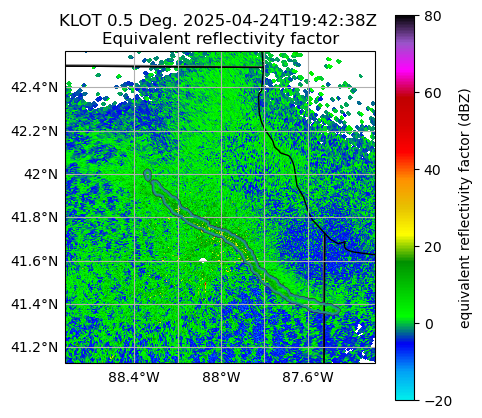

In [5]:
aidas.vis.visualize_lake_breeze(rad_scan, vmin=-20, 
                               vmax=80, cmap='NWSRef')

## 5. Instrument Steering

`aidas.util.azimuth_point` computes the azimuth from a ground instrument to the centroid of the largest detected lake breeze region. This tells an operator which direction to point a lidar or disdrometer to sample the front.

Here we place a virtual instrument at the **Argonne Testbed for Multiscale Observational Science (ATMOS)** in Lemont, IL (41.701°N, 87.996°W). The red dot marks the instrument position; the arrow shows the computed pointing direction; the blue × marks the lake breeze centroid.


Pointing azimuth: 133.1°   Lake breeze centroid: (41.648, -87.921)   Distance to front: 1.1 km


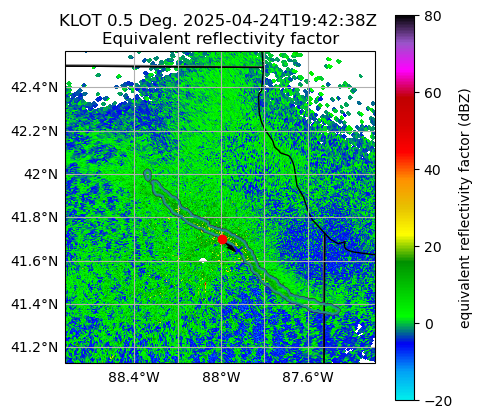

In [6]:
angle, lat, lon, dist = aidas.util.azimuth_point(-87.99577278662817, 41.70101404798476, rad_scan)
print(f"Pointing azimuth: {angle:.1f}°   Lake breeze centroid: ({lat:.3f}, {lon:.3f})   Distance to front: {dist/1000:.1f} km")
fig, ax = aidas.vis.visualize_lake_breeze(rad_scan, vmin=-20, 
                                        vmax=80, cmap='NWSRef')
ax.plot(-87.99577278662817, 41.70101404798476, 'ro', transform=ccrs.PlateCarree())
ax.quiver(-87.99577278662817, 41.70101404798476, 
          np.sin(np.deg2rad(angle)), np.cos(np.deg2rad(angle)), 
          transform=ccrs.PlateCarree(), color='k', scale=15)
ax.plot(lon, lat, 'bx', transform=ccrs.PlateCarree())


## 6. Mapping Lake Breeze Occurrence over a Full Day

Running inference across many scans lets us build an occurrence map — a count of how many times each grid point was flagged as lake breeze. This reveals the typical penetration depth and lateral extent of the front.

The `RadarImage` object provides several coordinate and indexing tools:

| Attribute / method | Description |
|---|---|
| `grid_lat`, `grid_lon` | 1-D arrays of latitude / longitude for each grid column and row |
| `grid_x`, `grid_y` | Easting / northing in metres relative to the domain centre |
| `lakebreeze_mask` | NumPy array of shape `(n_times, 256, 256)` containing binary lake breeze flags |
| `rad_scan[i]` | Mask for time index *i* |
| `rad_scan['2024-05-25T23:10:00']` | Mask aggregated to the nearest scan time |
| `rad_scan.aggregate(start, end)` | Sum of masks over the specified UTC time window |

The cell below demonstrates `aggregate`, which returns the pixel-wise sum of all masks between two timestamps.


In [10]:
rad_scan.aggregate('2024-05-25T23:10:00', 
                   '2024-05-25T23:59:00')

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256))

Integer and slice indexing are also supported and return the raw mask array(s) for those time steps, which is useful for frame-by-frame analysis or feeding individual masks into downstream tools.


In [11]:
rad_scan[0:1]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 256, 256))

(41.0, 43.0)

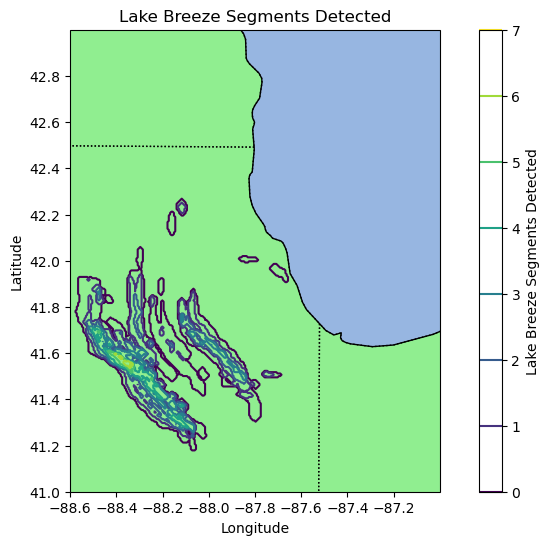

In [15]:
# Get the total number of lake breeze segments detected

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
plt.contour(rad_scan.grid_lon, rad_scan.grid_lat, rad_scan[:].sum(axis=0).T)
plt.colorbar(label='Lake Breeze Segments Detected')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, edgecolor='black')
ax.add_feature(cfeature.STATES, linestyle=':')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAND, facecolor='lightgreen')
ax.set_title('Lake Breeze Segments Detected on 25 May 2024')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks(np.arange(-88.6, -87, 0.2),
               crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(41, 43, 0.2),
               crs=ccrs.PlateCarree())
ax.set_xlim([-88.6, -87])
ax.set_ylim([41, 43])

## Summary

This notebook demonstrated the core AIDAS workflow for lake breeze detection:

- **`aidas.io.preprocess_radar_image`** / **`_batch`** — load and normalise NEXRAD data
- **`aidas.model.infer_lake_breeze`** / **`_batch`** — segment the lake breeze with a deep learning model
- **`aidas.vis.visualize_lake_breeze`** — overlay results on a geographic map
- **`aidas.util.azimuth_point`** — compute an instrument pointing direction toward the front centroid
- **`RadarImage.aggregate`** — summarise occurrence over a time window for climatological analysis

For questions or to report issues, see the project documentation or open a GitHub issue.
